In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
import math
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

## Random forrest

In [2]:
import pandas as pd
import numpy as np 

df = pd.read_csv("../../../Ch5/Notes/Dhruvil/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [5]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median())


In [7]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df['Sex'] = np.where(df['Sex']=='male',1,0)

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


In [10]:
x = df[['Pclass', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare']]
y = df['Survived']

In [11]:

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [12]:
from sklearn.ensemble import RandomForestClassifier
fr = RandomForestClassifier(criterion='entropy',n_estimators=101,random_state=1)
model = fr.fit(x_train,y_train)
y_pred = fr.predict(x_test)
y_pred

array([1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1])

In [13]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(f'\n Accuracy score: {accuracy_score(y_test,y_pred)}')

[[95 11]
 [28 45]]

 Accuracy score: 0.7821229050279329


In [14]:
diff = pd.DataFrame({'Actual': y_test, 'Prediction': y_pred})
diff.head()

,Actual,Prediction
862,1,1
223,0,0
84,1,1
680,0,0
535,1,1


In [15]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[95, 11],
       [28, 45]])

In [16]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]



In [17]:
from sklearn.metrics import accuracy_score

print('Accuracy Score ', accuracy_score(y_test,y_pred))

Accuracy Score  0.7821229050279329


#### Error rate

In [18]:
print('Error rate ', 1-accuracy_score(y_test,y_pred))

Error rate  0.2178770949720671


#### Sensitivity

In [ ]:
print('Sensitivity  ',(TP/(TP+FN)))

Sensitivity   0.6164383561643836


#### Specificity

In [19]:
print('Specificity ',(TN/(TN+FP)))

Specificity  0.8962264150943396


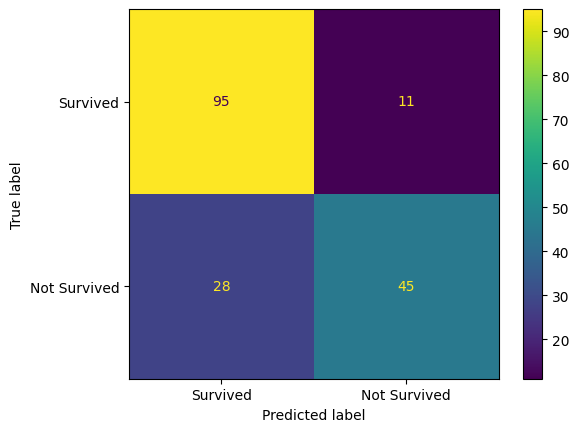

In [20]:
import matplotlib.pyplot as plt 
from sklearn import metrics

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Survived','Not Survived'])
cm_display.plot()
plt.show()

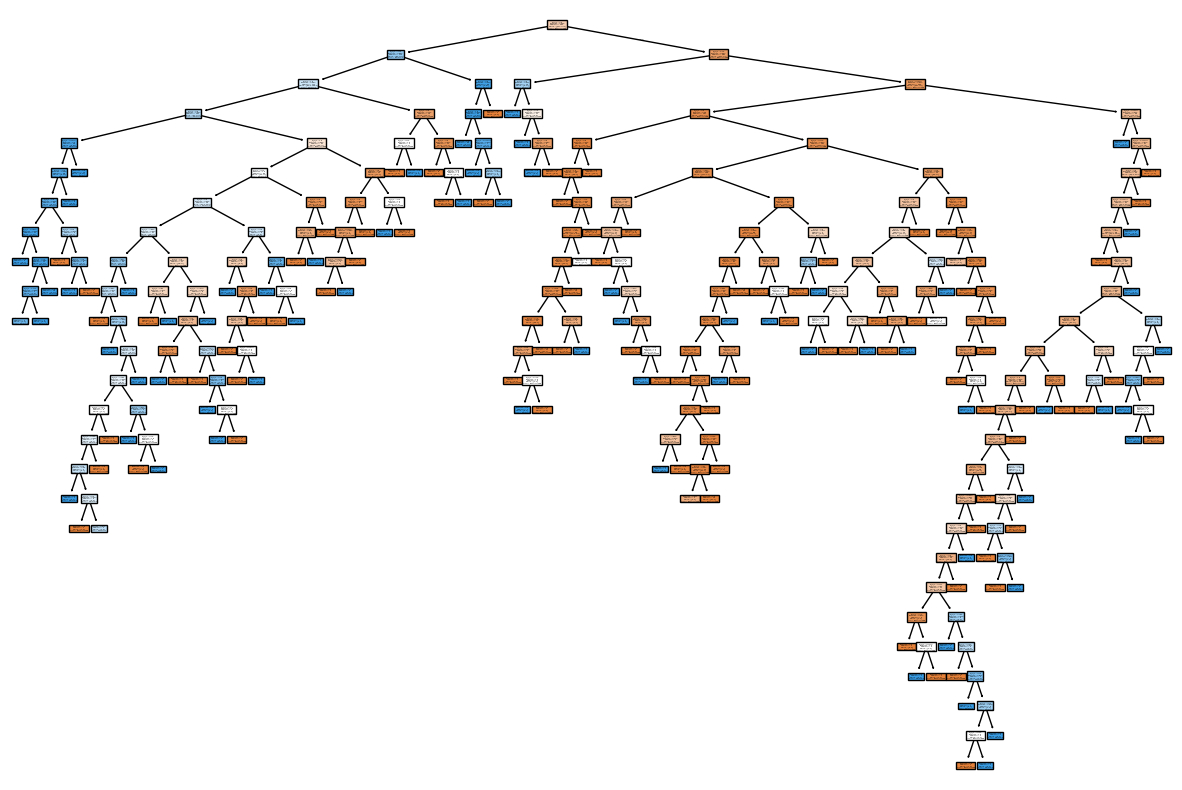

In [21]:
import matplotlib.pyplot as plt 
from sklearn.tree import plot_tree

choose_tree = model.estimators_[0]
plt.figure(figsize=(15,10))
plot_tree(choose_tree,filled=True,class_names=['Not Survived','Survived'])
plt.show()

In [22]:
df = pd.DataFrame({'Weight': [150,170,140,180,160,155],
                    'Texture': ['Smooth','Rough','Smooth','Rough','Smooth','Rough'],
                    'Color': [0,1,2,1,0,3],
                    'Fruit': ['Apple','Orange','Apple','Orange','Apple','Orange']})
df.head()

,Weight,Texture,Color,Fruit
0,150,Smooth,0,Apple
1,170,Rough,1,Orange
2,140,Smooth,2,Apple
3,180,Rough,1,Orange
4,160,Smooth,0,Apple


In [23]:
df['Texture'] = np.where(df['Texture']=='Smooth',0,1)

In [24]:
df

,Weight,Texture,Color,Fruit
0,150,0,0,Apple
1,170,1,1,Orange
2,140,0,2,Apple
3,180,1,1,Orange
4,160,0,0,Apple
5,155,1,3,Orange


In [25]:
x = df[['Weight','Texture','Color']]
y = df['Fruit']

In [26]:

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [27]:
from sklearn.ensemble import RandomForestClassifier
fr = RandomForestClassifier(criterion='entropy',n_estimators=101,random_state=1)
model = fr.fit(x_train,y_train)
y_pred = fr.predict(x_test)
y_pred

array(['Apple', 'Orange'], dtype=object)

In [28]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm = confusion_matrix(y_test,y_pred)
print(cm)
print(f'\n Accuracy score: {accuracy_score(y_test,y_pred)}')

[[1 0]
 [0 1]]

 Accuracy score: 1.0


In [29]:
diff = pd.DataFrame({'Actual': y_test, 'Prediction': y_pred})
diff.head()

,Actual,Prediction
2,Apple,Apple
1,Orange,Orange


In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[1, 0],
       [0, 1]])

In [31]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]



In [32]:
from sklearn.metrics import accuracy_score

print('Accuracy Score ', accuracy_score(y_test,y_pred))

Accuracy Score  1.0


#### Error rate

In [33]:
print('Error rate ', 1-accuracy_score(y_test,y_pred))

Error rate  0.0


#### Sensitivity

In [34]:
print('Sensitivity  ',(TP/(TP+FN)))

Sensitivity   1.0


#### Specificity

In [35]:
print('Specificity ',(TN/(TN+FP)))

Specificity  1.0


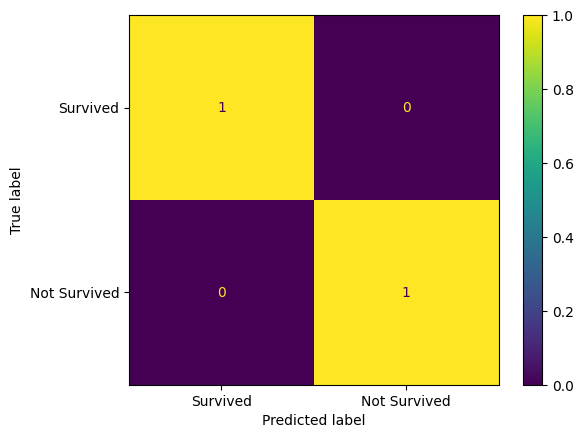

In [36]:
from numpy.linalg import cond

import matplotlib.pyplot as plt 
from sklearn import metrics

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Survived','Not Survived'])
cm_display.plot()
plt.show()

In [37]:
df = pd.read_csv("../../../../PYTHON-2-DATASET-main/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [39]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [41]:
y = df["Outcome"]
x = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age']]

In [42]:

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [43]:
from sklearn import svm

classifier= svm.SVC(kernel="rbf", C=1.0,random_state=0)
model= classifier.fit(x_train,y_train)
y_pred = model.predict(x_test)
y_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [44]:
diff = pd.DataFrame({'Actual': y_test, 'Prediction': y_pred})
diff.head()

,Actual,Prediction
285,0,0
101,0,1
581,0,0
352,0,0
726,0,0


In [45]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[93,  6],
       [27, 28]])

In [46]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]



In [47]:
from sklearn.metrics import accuracy_score

print('Accuracy Score ', accuracy_score(y_test,y_pred))

Accuracy Score  0.7857142857142857


#### Error rate

In [48]:
print('Error rate ', 1-accuracy_score(y_test,y_pred))

Error rate  0.2142857142857143


#### Sensitivity

In [ ]:
print('Sensitivity  ',(TP/(TP+FN)))

Sensitivity   0.509090909090909


#### Specificity

In [51]:
print('Specificity ',(TN/(TN+FP)))

Specificity  0.9393939393939394
